Loading...
All pipelines subsampled to match Enterprise (N = 72001)
My QCW: 72,001, Loki: 72,001, Enterprise: 72,001


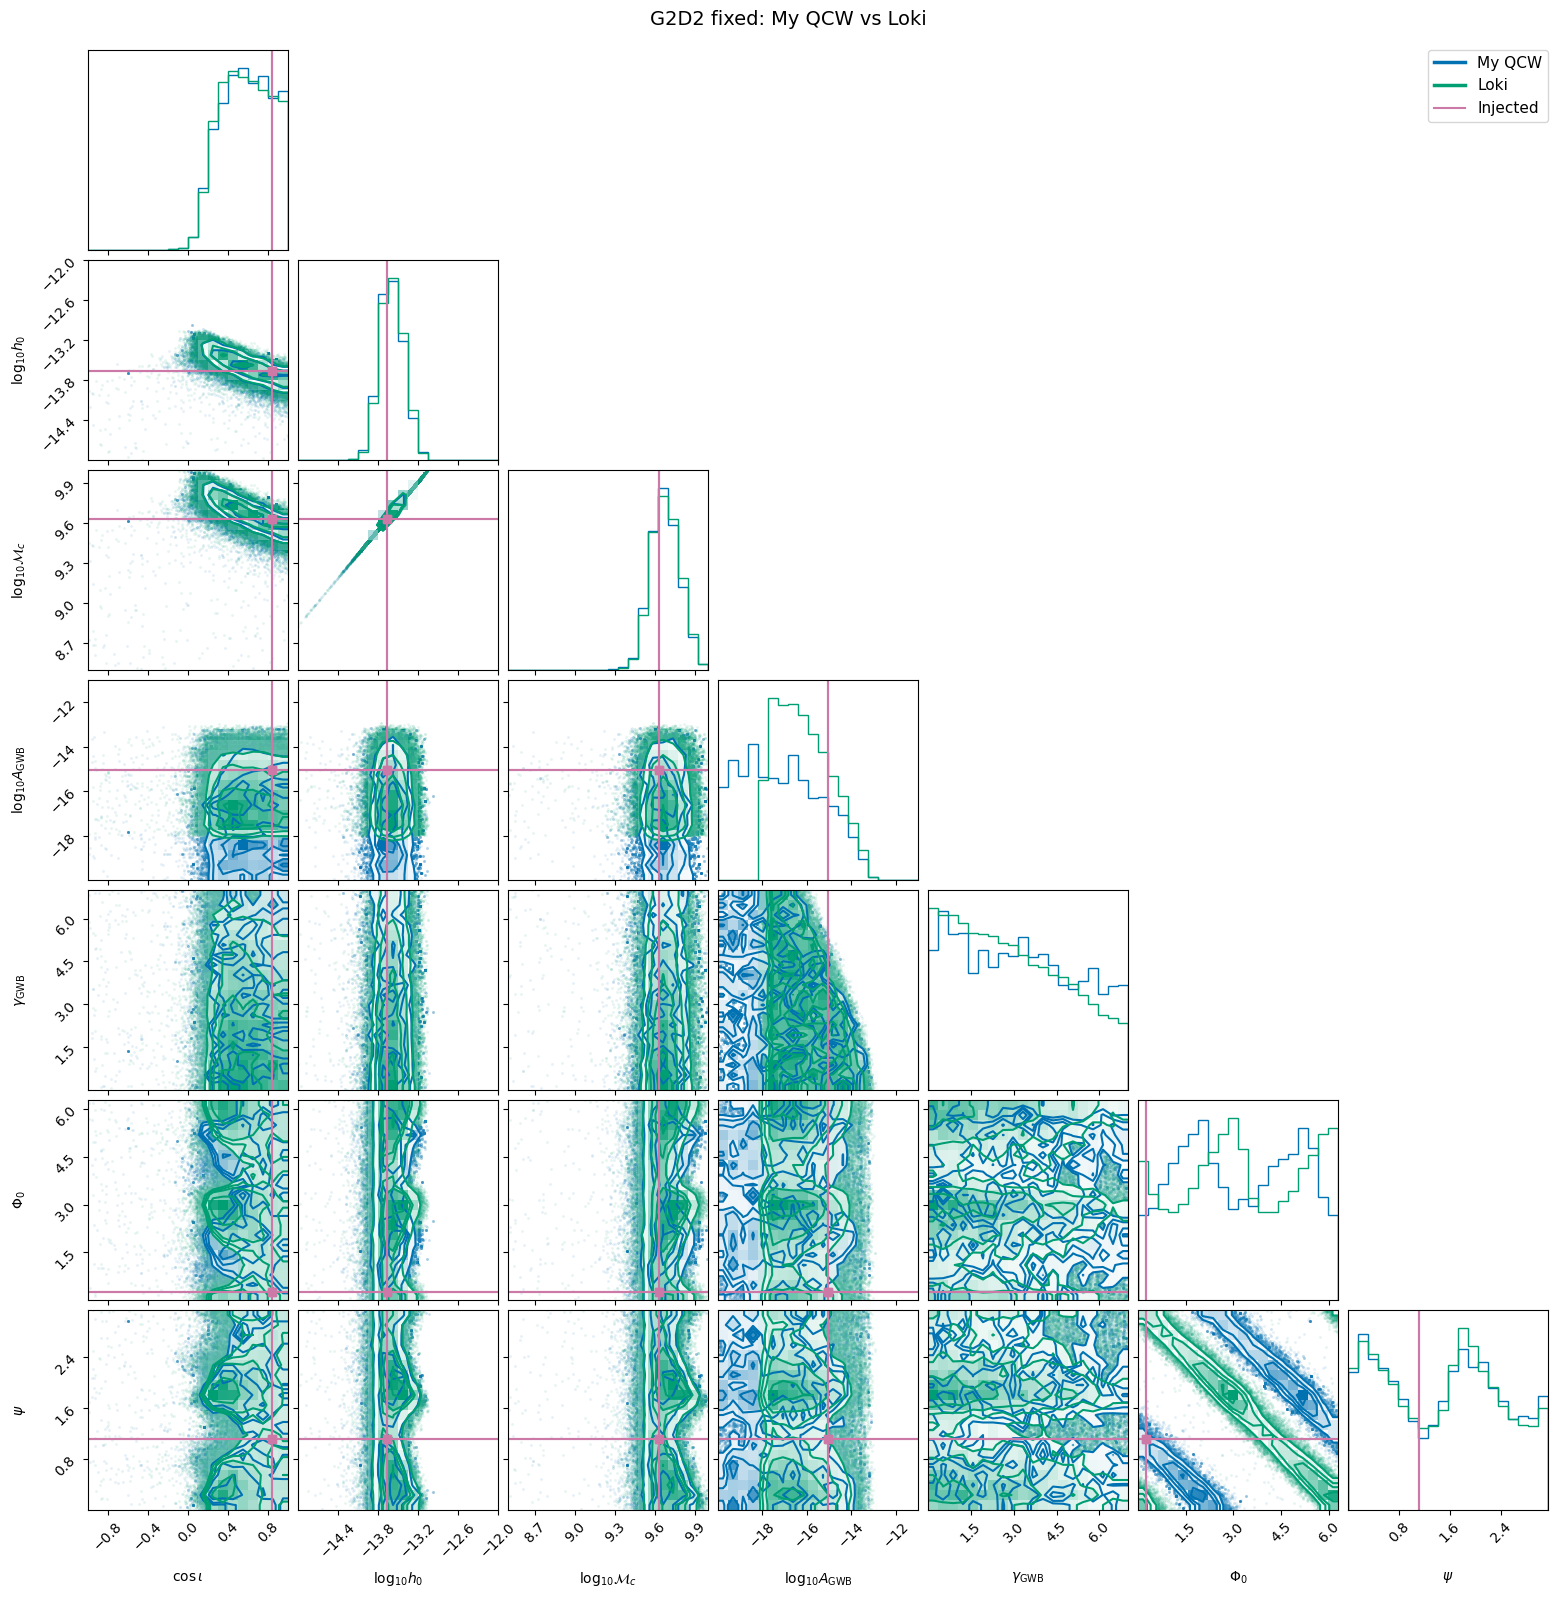

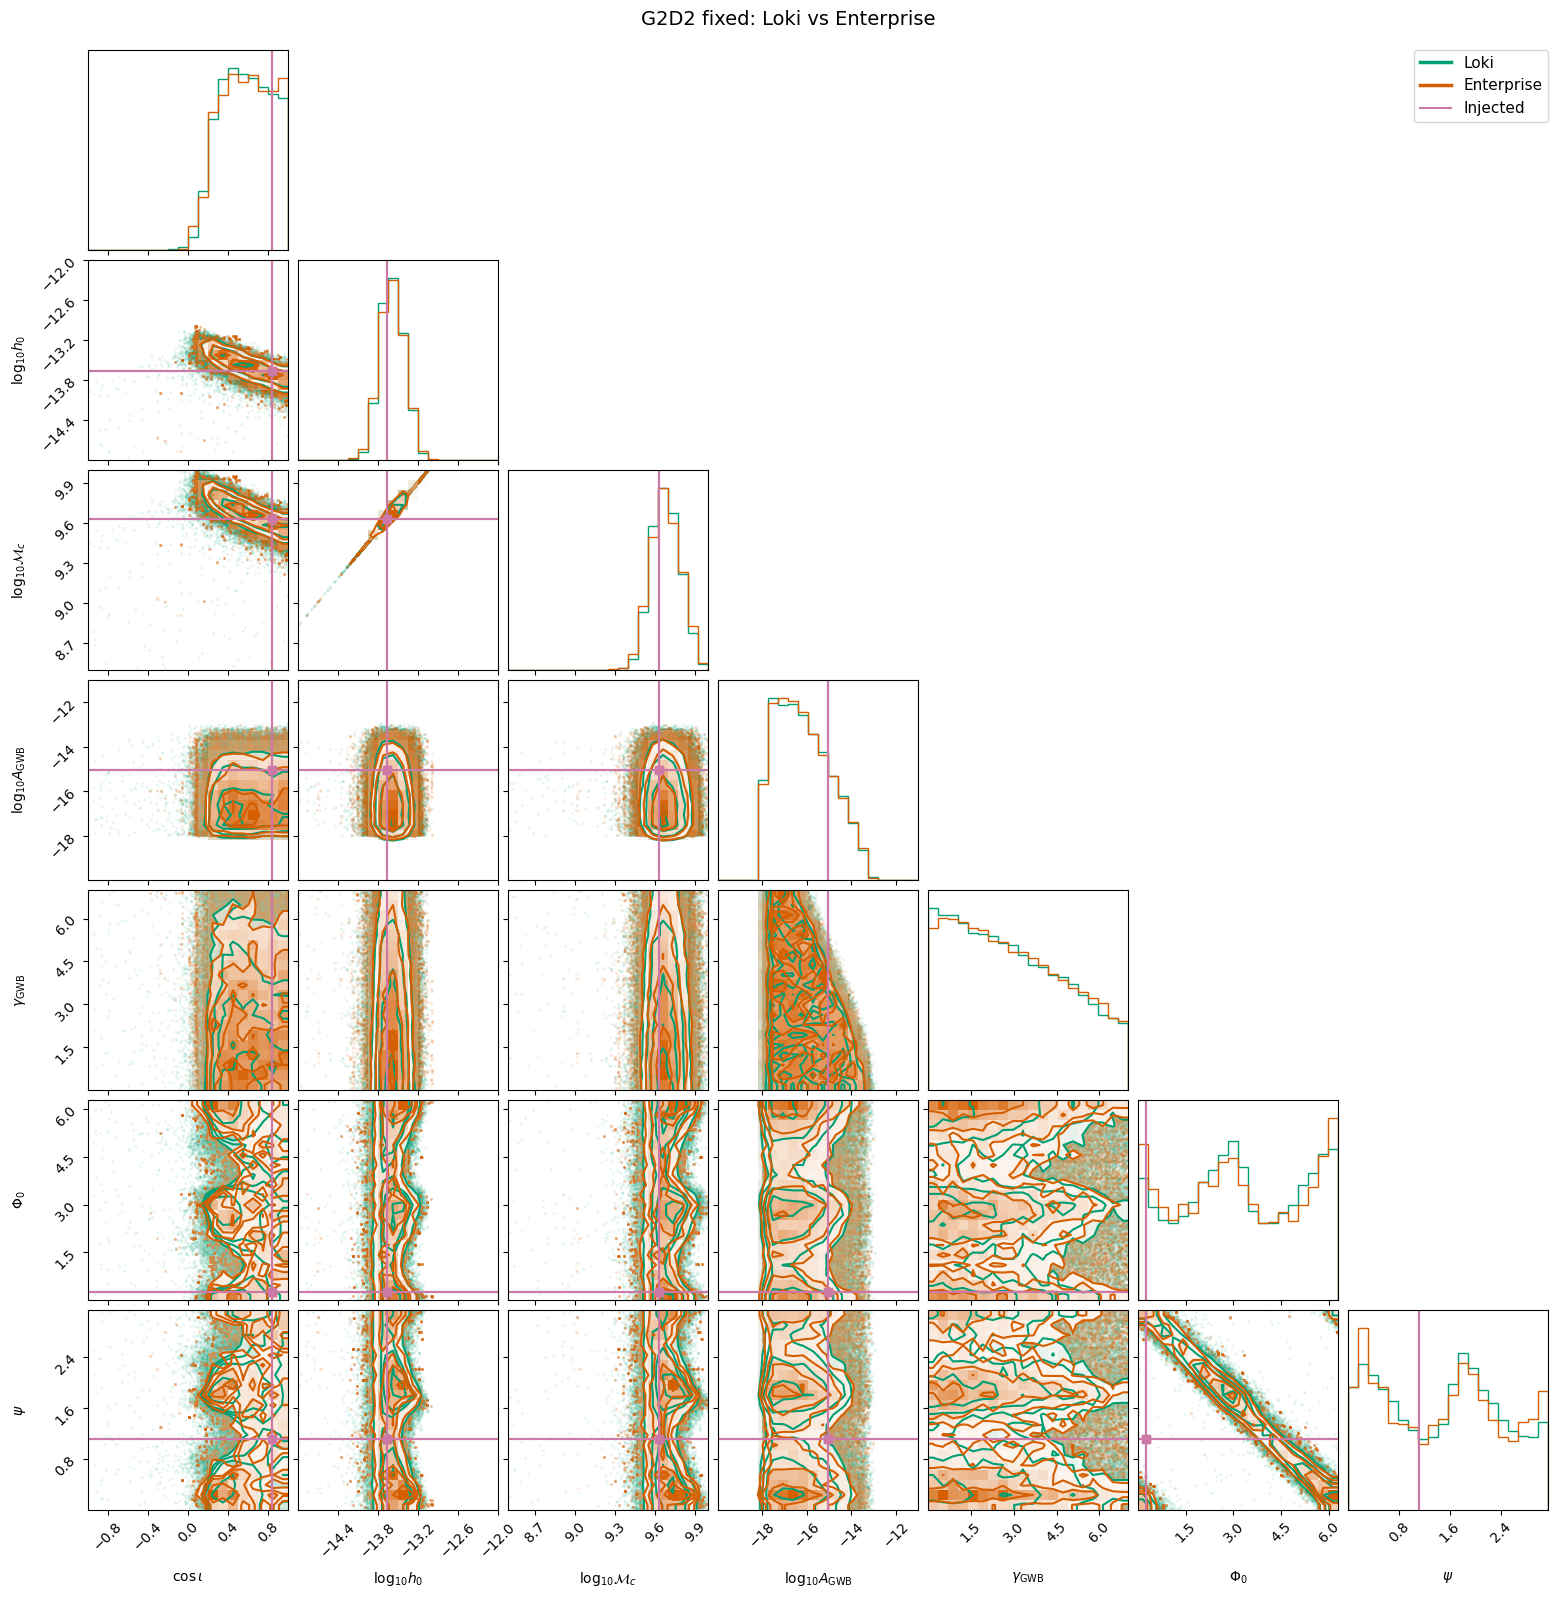

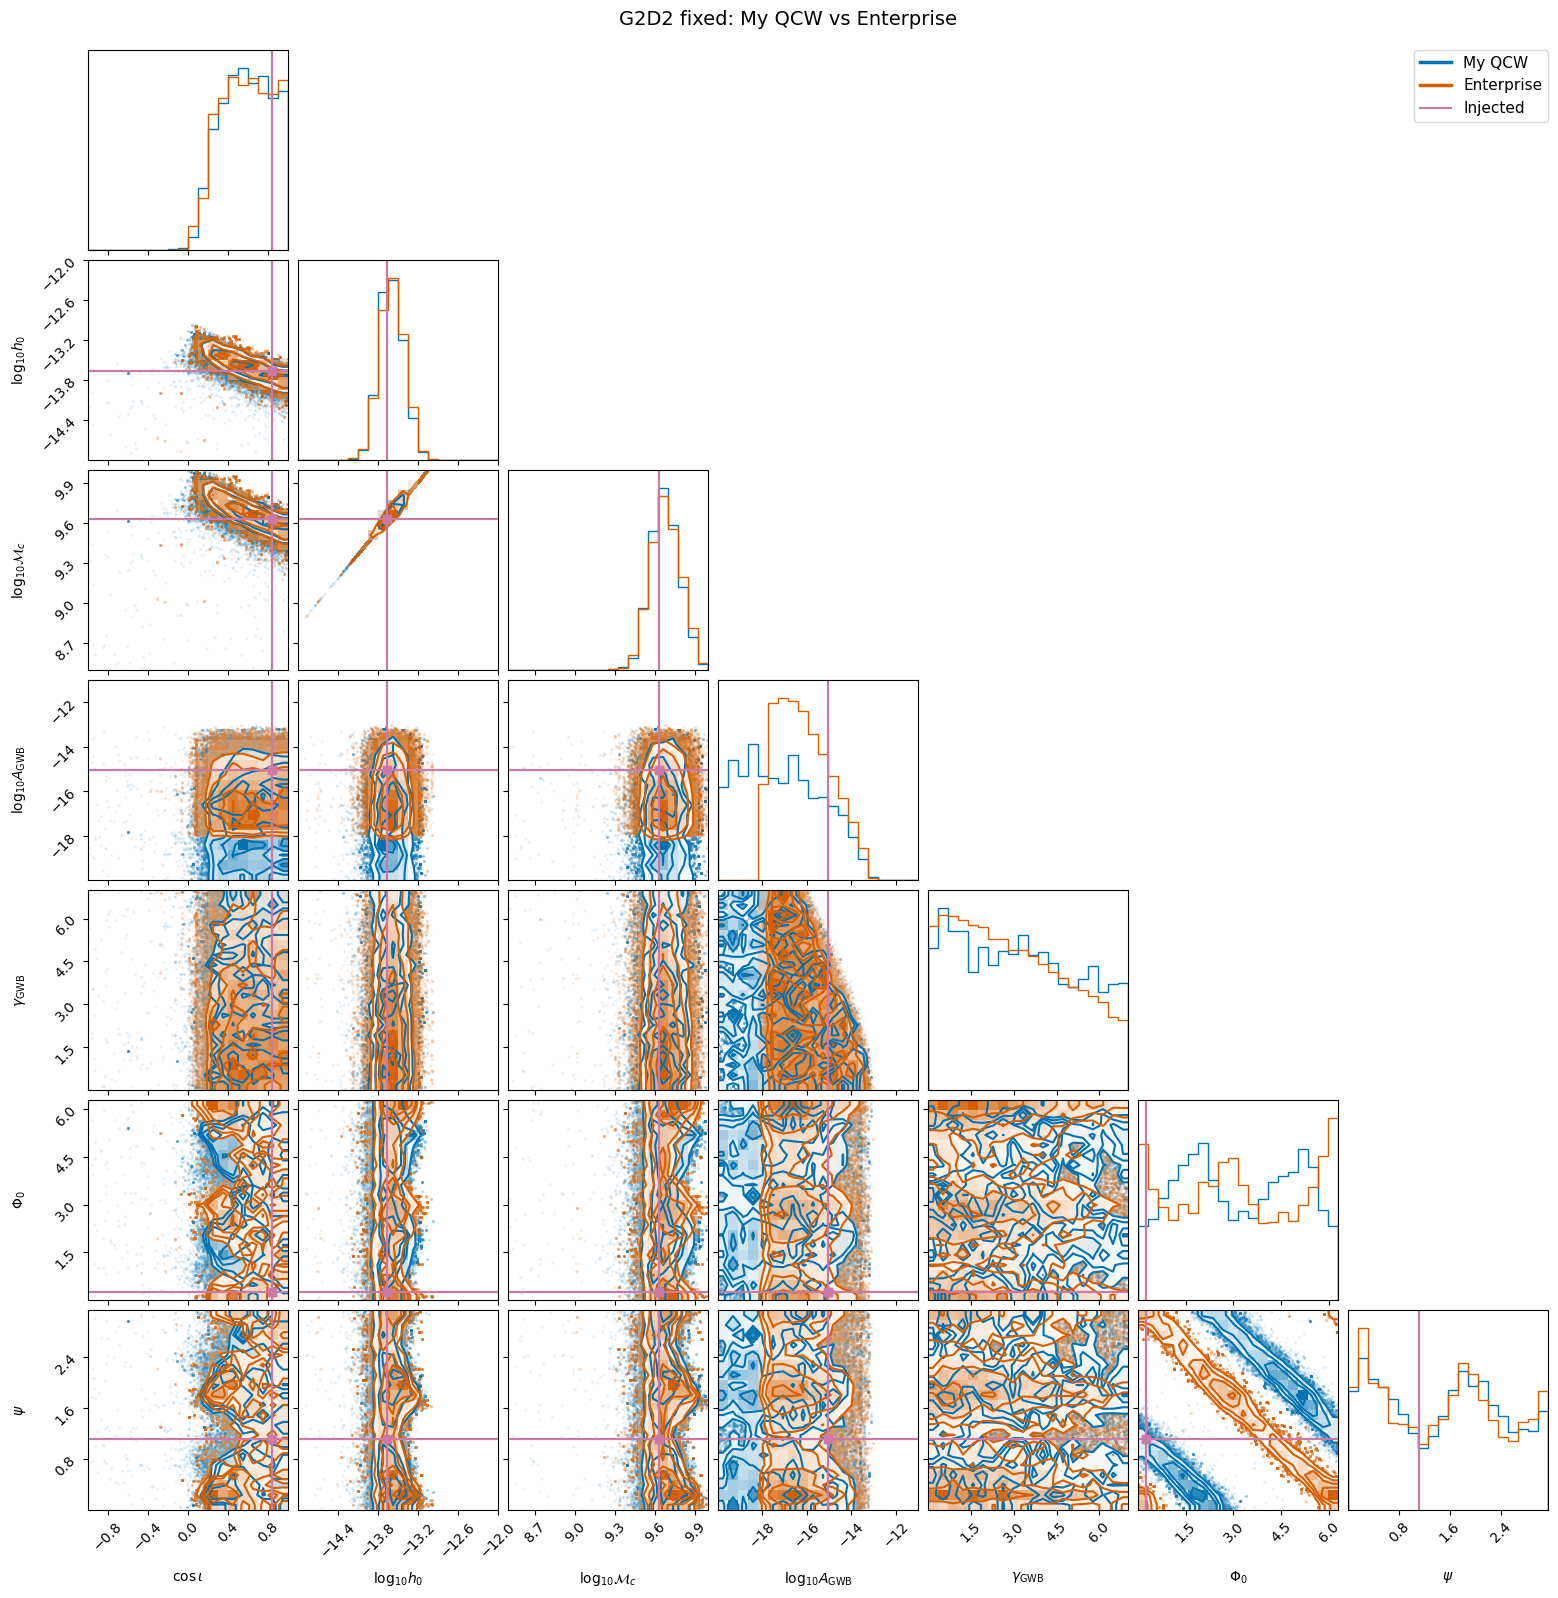

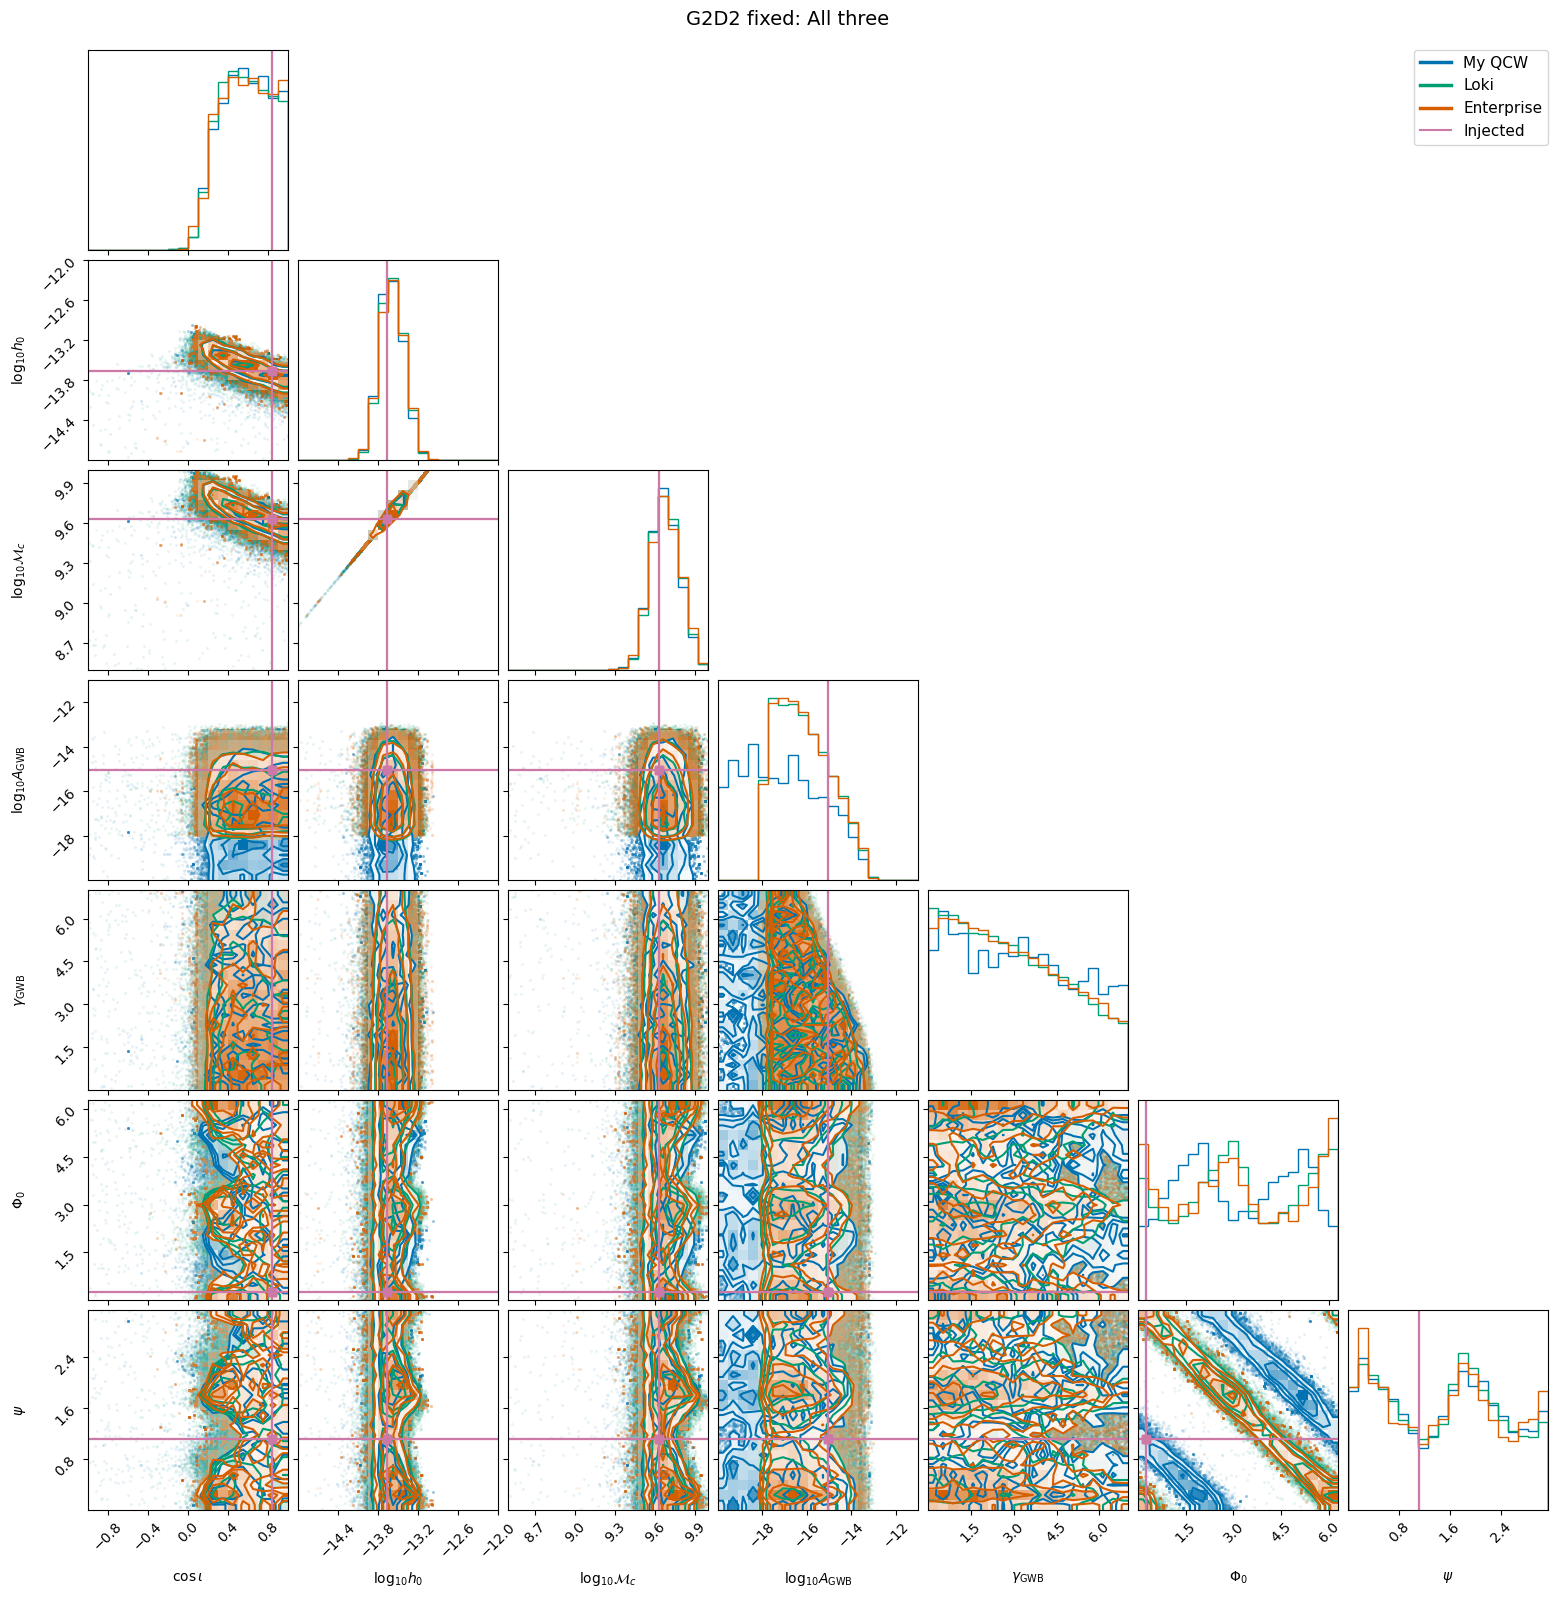

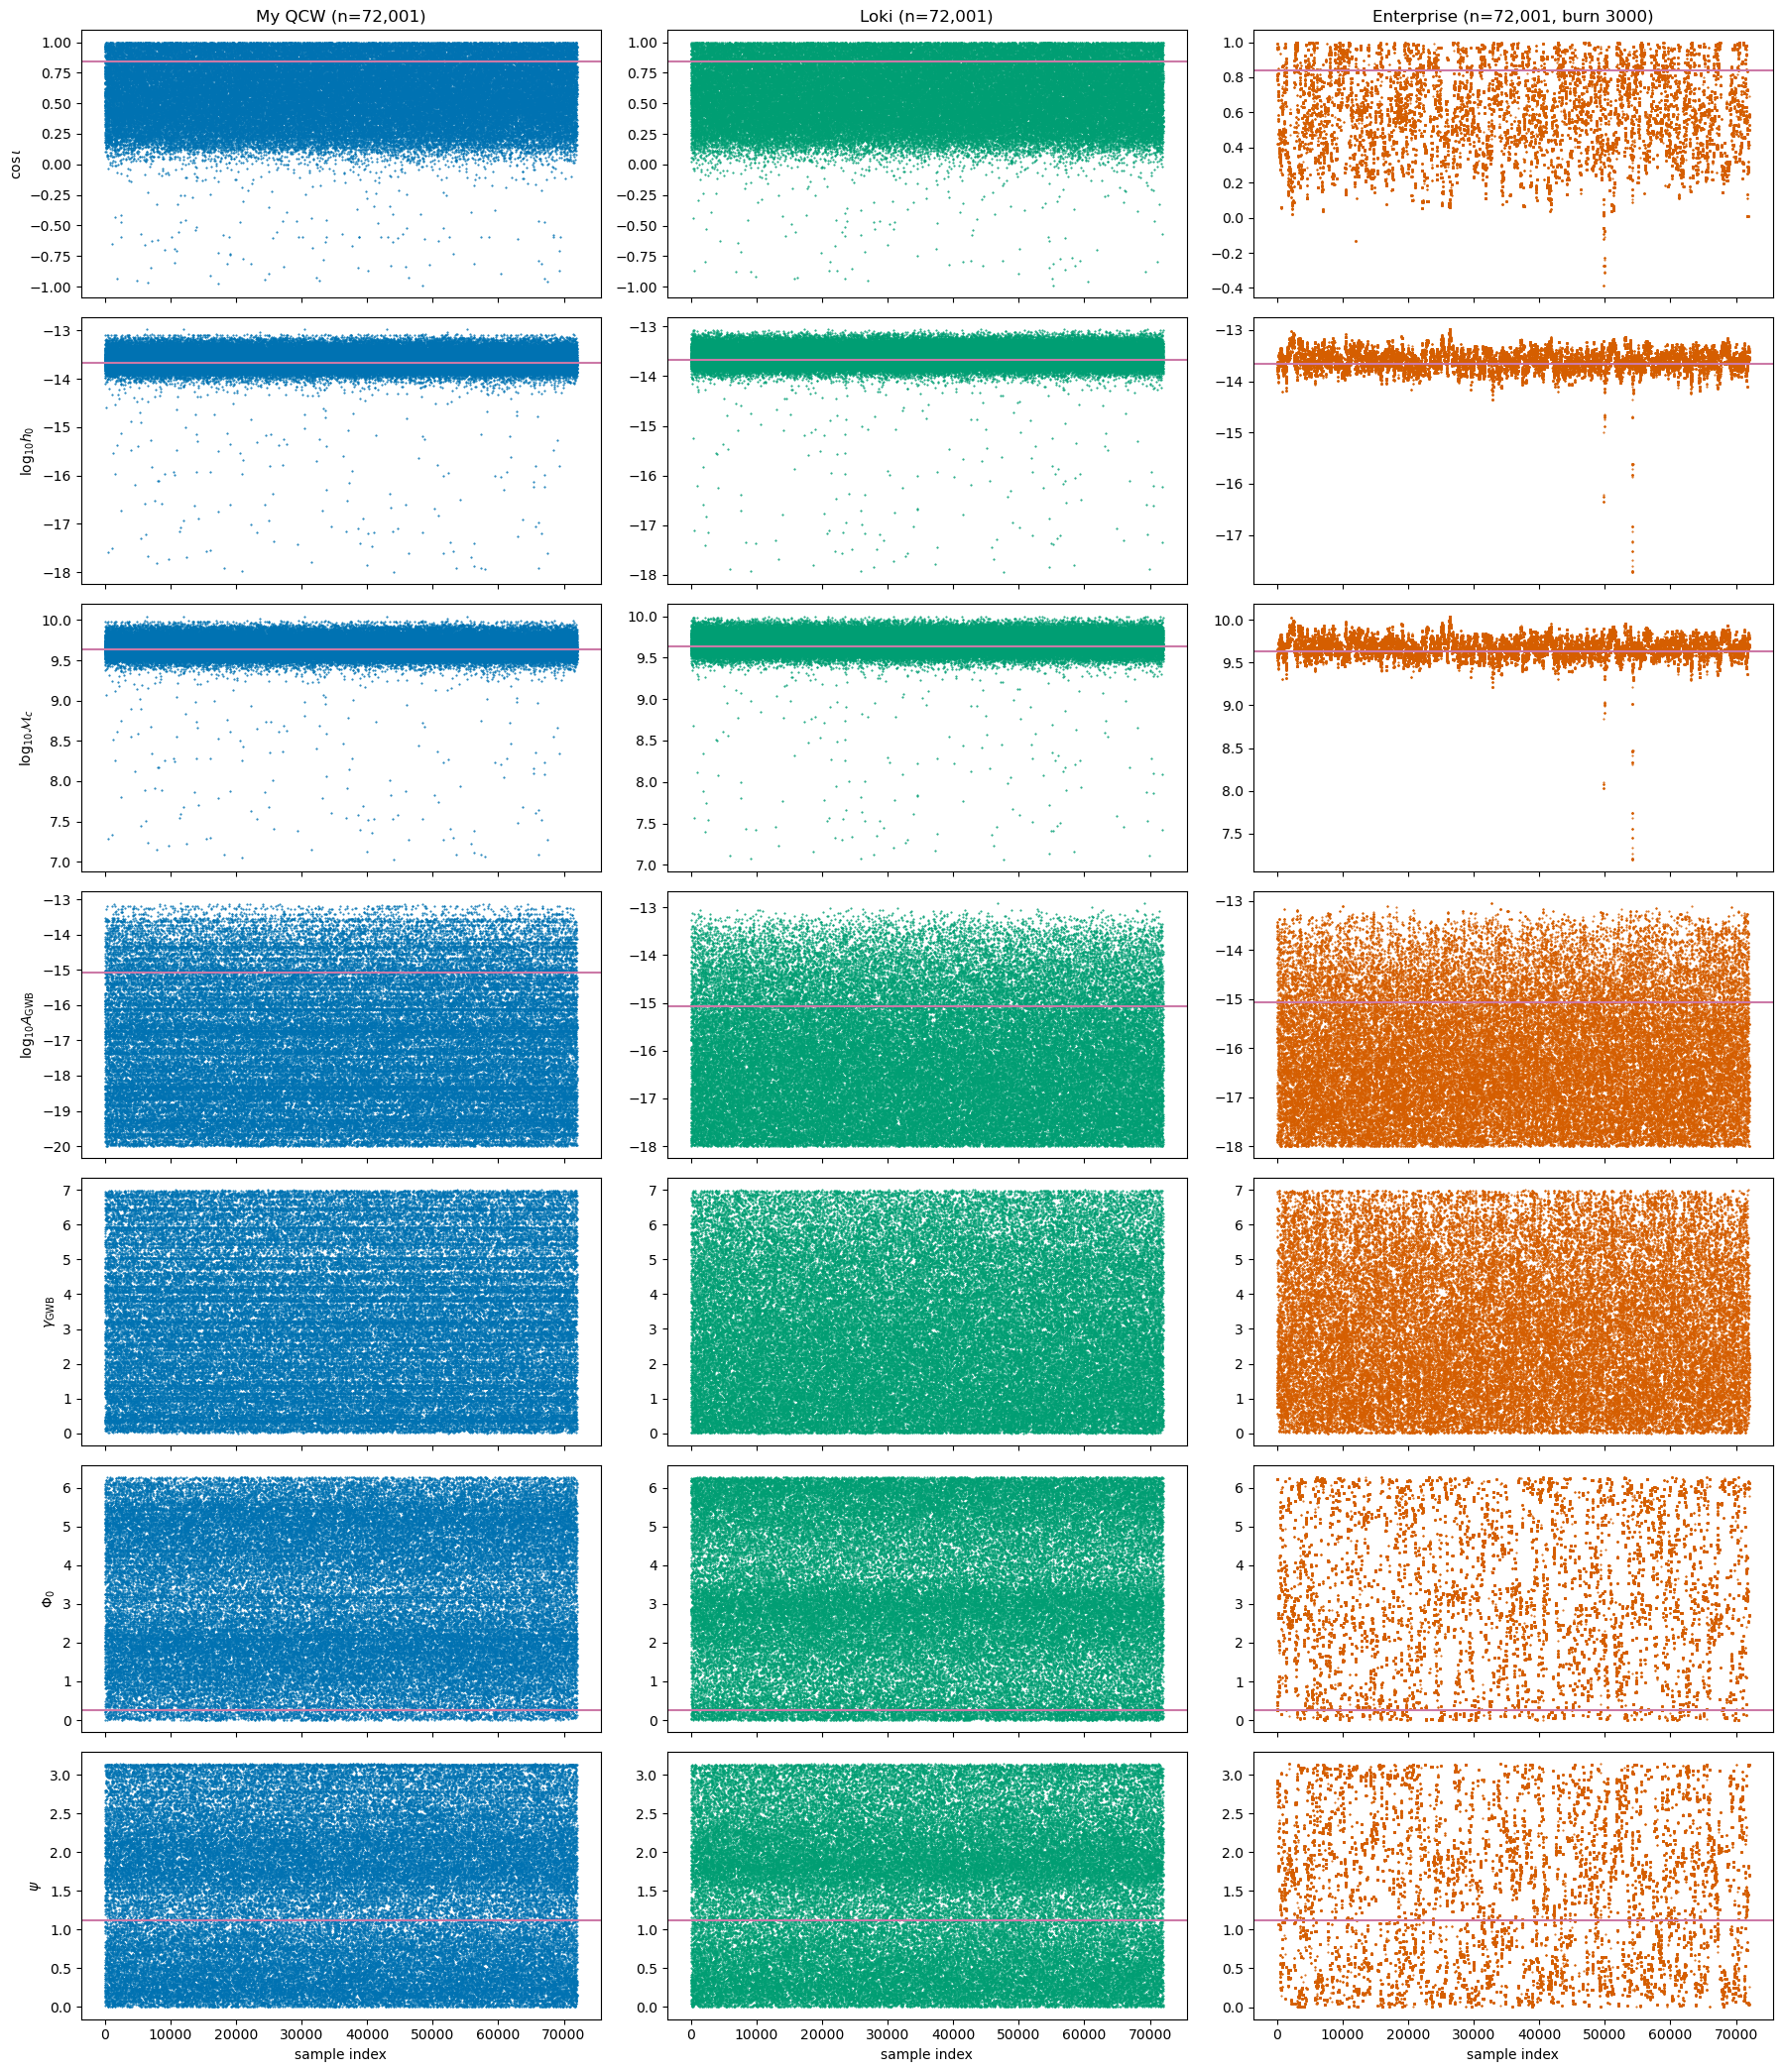


Parameter ranges (fGW fixed at log10 = -8.4318)

My QCW (n=72,001):
  cos_inc: [-0.989, 1.000]  median=0.586
  log10_h0: [-17.999, -12.975]  median=-13.606
  log10_Mc: [7.033, 10.048]  median=9.671
  log10_A_GWB: [-20.000, -13.111]  median=-17.239
  gamma_GWB: [0.001, 6.999]  median=3.159
  phase0: [0.000, 6.283]  median=3.096
  psi: [0.000, 3.141]  median=1.580

Loki (n=72,001):
  cos_inc: [-0.988, 1.000]  median=0.574
  log10_h0: [-17.944, -13.054]  median=-13.594
  log10_Mc: [7.069, 10.000]  median=9.679
  log10_A_GWB: [-18.000, -12.913]  median=-16.284
  gamma_GWB: [0.000, 7.000]  median=2.731
  phase0: [0.000, 6.283]  median=3.133
  psi: [0.000, 3.142]  median=1.587

Ent (n=72,001):
  cos_inc: [-0.384, 1.000]  median=0.587
  log10_h0: [-17.727, -12.984]  median=-13.592
  log10_Mc: [7.199, 10.045]  median=9.679
  log10_A_GWB: [-18.000, -13.043]  median=-16.292
  gamma_GWB: [0.000, 6.999]  median=2.784
  phase0: [0.001, 6.282]  median=3.066
  psi: [0.000, 3.141]  median=1.562


In [2]:
%matplotlib inline
import numpy as np
import h5py
import matplotlib.pyplot as plt
import corner

np.random.seed(42)

QCW_FILE = "/scratch/na00078/projects/IPTA_MDC2/h5_files/dl_masked/G2D2_narrow_detect_dLmasked_75.400Mpc.h5"
LOKI_FILE = "/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_fixed_detect_loki_100M_lastTOA_02_Jun_2026.h5"
ENT_FILE = "/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_core_fixed_new.h5"

ENT_BURN = 3000

# constants
megaparsec = 3.086e+22
speed_of_light = 299792458.0
T_sun = 1.327124400e20 / speed_of_light**3
D_MPC_FIXED = 75.400
F_GW_FIXED = np.log10(3.7e-9)  # injected fGW for fixed runs

def derive_log10_h0(log10_mc, log10_fgw, log10_dL_Mpc):
    return (np.log10(2.0)
            + (5.0/3.0) * (log10_mc + np.log10(T_sun))
            + (2.0/3.0) * (np.log10(np.pi) + log10_fgw)
            - (log10_dL_Mpc + np.log10(megaparsec) - np.log10(speed_of_light)))

# load
print("Loading...")
with h5py.File(QCW_FILE, "r") as f:
    qc = f["samples_masked"][...]
    qc_pn = [p.decode() if isinstance(p, bytes) else p for p in f["par_names"][:]]
with h5py.File(LOKI_FILE, "r") as f:
    lk = f["samples_cold"][0, :, :]
    lk_pn = [p.decode() if isinstance(p, bytes) else p for p in f["par_names"][:]]
with h5py.File(ENT_FILE, "r") as f:
    en_all = f["chain"][...]
    en_pn = [p.decode() if isinstance(p, bytes) else p for p in f["params"][:]]

# Enterprise: apply burn-in
en = en_all[ENT_BURN:, :]

# subsample QCW and Loki to match Enterprise post burn-in
N_TARGET = len(en)
qc_idx = np.random.choice(len(qc), min(N_TARGET, len(qc)), replace=False)
qc_sub = qc[qc_idx]
lk_idx = np.random.choice(len(lk), N_TARGET, replace=False)
lk_sub = lk[lk_idx]

print(f"All pipelines subsampled to match Enterprise (N = {N_TARGET})")
print(f"My QCW: {len(qc_sub):,}, Loki: {len(lk_sub):,}, Enterprise: {len(en):,}")

# extract (no fGW since it's fixed)
qcw_cosi = qc_sub[:, qc_pn.index("0_cos_inc")]
qcw_h    = qc_sub[:, qc_pn.index("0_log10_h")]
qcw_mc   = qc_sub[:, qc_pn.index("0_log10_mc")]
qcw_amp  = qc_sub[:, qc_pn.index("gwb_log10_A")]
qcw_gam  = qc_sub[:, qc_pn.index("gwb_gamma")]
qcw_phi  = qc_sub[:, qc_pn.index("0_phase0")]
qcw_psi  = qc_sub[:, qc_pn.index("0_psi")]

loki_cosi = lk_sub[:, lk_pn.index("0_cos_inc")]
loki_mc   = lk_sub[:, lk_pn.index("0_log10_mc")]
loki_dist = lk_sub[:, lk_pn.index("0_log10_dist")]
loki_h    = derive_log10_h0(loki_mc, np.full_like(loki_mc, F_GW_FIXED), loki_dist)
loki_amp  = lk_sub[:, lk_pn.index("gwb_log10_A")]
loki_gam  = lk_sub[:, lk_pn.index("gwb_gamma")]
loki_phi  = lk_sub[:, lk_pn.index("0_phase0")]
loki_psi  = lk_sub[:, lk_pn.index("0_psi")]

ent_cosi = en[:, en_pn.index("cos_inc")]
ent_mc   = en[:, en_pn.index("log10_mc")]
ent_h    = derive_log10_h0(ent_mc, np.full_like(ent_mc, F_GW_FIXED),
                           np.full_like(ent_mc, np.log10(D_MPC_FIXED)))
ent_amp  = en[:, en_pn.index("crn_log10_A")]
ent_gam  = en[:, en_pn.index("crn_gamma")]
ent_phi  = en[:, en_pn.index("phase0")]
ent_psi  = en[:, en_pn.index("psi")]

# injected truth values (from MDC2 JSON, no fGW since it's fixed)
t_cosi = 0.8412486994612669
t_h    = -13.668773493298787
t_mc   = np.log10(4.3e9)
t_amp  = -15.070581074285707
t_phi  = 0.24434609527920614
t_psi  = 1.1187560505283651
# gamma_GWB is not in the injection JSON

CB, CG, CO, CT = "#0072B2", "#009E73", "#D55E00", "#CC79A7"

# corner setup (7 params, no fGW)
labels_c = [r"$\cos\iota$", r"$\log_{10} h_0$",
            r"$\log_{10}\mathcal{M}_c$", r"$\log_{10} A_{\rm GWB}$",
            r"$\gamma_{\rm GWB}$", r"$\Phi_0$", r"$\psi$"]
ranges_c = [(-1, 1), (-15, -12), (8.5, 10.0), (-20, -11),
            (0, 7), (0, 2*np.pi), (0, np.pi)]
truths_c = [t_cosi, t_h, t_mc, t_amp, None, t_phi, t_psi]

qcw_c  = np.column_stack([qcw_cosi, qcw_h, qcw_mc, qcw_amp, qcw_gam, qcw_phi, qcw_psi])
loki_c = np.column_stack([loki_cosi, loki_h, loki_mc, loki_amp, loki_gam, loki_phi, loki_psi])
ent_c  = np.column_stack([ent_cosi, ent_h, ent_mc, ent_amp, ent_gam, ent_phi, ent_psi])

def make_corner(data_list, color_list, label_list, title):
    fig = corner.corner(data_list[0], labels=labels_c, truths=truths_c,
                        truth_color=CT, range=ranges_c, color=color_list[0])
    for d, c in zip(data_list[1:], color_list[1:]):
        corner.corner(d, fig=fig, labels=labels_c, truths=truths_c,
                      truth_color=CT, range=ranges_c, color=c)
    handles = [plt.Line2D([0],[0], color=c, lw=2.5, label=l)
               for c, l in zip(color_list, label_list)]
    handles.append(plt.Line2D([0],[0], color=CT, lw=1.5, label="Injected"))
    fig.legend(handles=handles, loc="upper right", fontsize=11,
               bbox_to_anchor=(0.98, 0.98))
    fig.suptitle(title, fontsize=14, y=1.0)
    return fig

# corner plots
make_corner([qcw_c, loki_c], [CB, CG],
            ["My QCW", "Loki"], "G2D2 fixed: My QCW vs Loki")
plt.show()

make_corner([loki_c, ent_c], [CG, CO],
            ["Loki", "Enterprise"], "G2D2 fixed: Loki vs Enterprise")
plt.show()

make_corner([qcw_c, ent_c], [CB, CO],
            ["My QCW", "Enterprise"], "G2D2 fixed: My QCW vs Enterprise")
plt.show()

make_corner([qcw_c, loki_c, ent_c], [CB, CG, CO],
            ["My QCW", "Loki", "Enterprise"], "G2D2 fixed: All three")
plt.show()

# trace plots (7 rows, no fGW)
trace_rows = [
    (r"$\cos\iota$",              t_cosi, [(qcw_cosi, CB), (loki_cosi, CG), (ent_cosi, CO)]),
    (r"$\log_{10}h_0$",           t_h,    [(qcw_h, CB),    (loki_h, CG),    (ent_h, CO)]),
    (r"$\log_{10}\mathcal{M}_c$", t_mc,   [(qcw_mc, CB),   (loki_mc, CG),   (ent_mc, CO)]),
    (r"$\log_{10}A_{\rm GWB}$",   t_amp,  [(qcw_amp, CB),  (loki_amp, CG),  (ent_amp, CO)]),
    (r"$\gamma_{\rm GWB}$",       None,   [(qcw_gam, CB),  (loki_gam, CG),  (ent_gam, CO)]),
    (r"$\Phi_0$",                 t_phi,  [(qcw_phi, CB),  (loki_phi, CG),  (ent_phi, CO)]),
    (r"$\psi$",                   t_psi,  [(qcw_psi, CB),  (loki_psi, CG),  (ent_psi, CO)]),
]

titles = [f"My QCW (n={len(qcw_cosi):,})",
          f"Loki (n={len(loki_cosi):,})",
          f"Enterprise (n={len(ent_cosi):,}, burn {ENT_BURN})"]

fig, axes = plt.subplots(len(trace_rows), 3, figsize=(18, 21), sharex="col")
for row_i, (ylabel, truth_val, data) in enumerate(trace_rows):
    for col_i, (arr, color) in enumerate(data):
        axes[row_i, col_i].plot(arr, marker=".", linestyle="None",
                                markersize=1, color=color, rasterized=True)
        if truth_val is not None:
            axes[row_i, col_i].axhline(truth_val, color=CT, lw=1.5)
    axes[row_i, 0].set_ylabel(ylabel)

for col_i, t in enumerate(titles):
    axes[0, col_i].set_title(t)
for col_i in range(3):
    axes[-1, col_i].set_xlabel("sample index")

plt.tight_layout()
plt.show()

# parameter ranges
print("\n" + "=" * 70)
print("Parameter ranges (fGW fixed at log10 = -8.4318)")
print("=" * 70)
all_labels = ["cos_inc", "log10_h0", "log10_Mc",
              "log10_A_GWB", "gamma_GWB", "phase0", "psi"]

for name, arrs in [
    ("My QCW", (qcw_cosi, qcw_h, qcw_mc, qcw_amp, qcw_gam, qcw_phi, qcw_psi)),
    ("Loki",   (loki_cosi, loki_h, loki_mc, loki_amp, loki_gam, loki_phi, loki_psi)),
    ("Ent",    (ent_cosi, ent_h, ent_mc, ent_amp, ent_gam, ent_phi, ent_psi)),
]:
    print(f"\n{name} (n={len(arrs[0]):,}):")
    for lab, a in zip(all_labels, arrs):
        print(f"  {lab}: [{a.min():.3f}, {a.max():.3f}]  median={np.median(a):.3f}")